 # Whisper Accent Robustness — Model Performance Evaluation



 Run `eval_model_perf.py` on SLURM first to generate the CSVs this notebook reads.



 - **Scripted**     → 6 held-out test speakers (never seen during training)

 - **Spontaneous**  → suitcase corpus (OOD, all speakers)



 Metrics:

 - **WER**  — word error rate (primary ASR metric)

 - **PER**  — phoneme error rate via G2P; labelled "PER (G2P)" throughout

In [47]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = "results/model_perf_comparison"

# Keys must match {model_key} in CSV filenames; values are display labels
MODEL_KEYS = {
    "baseline":      "Zero-shot",
    # "baseline_lora": "Naive LoRA FT",
    "no_aux":        "Naive LoRA FT",
    "no_aux_heldout_chinese":        "Naive LoRA FT (heldout Chinese)",
    # "ctc_aux_l3":    "CTC Aux",
    "feat_aux":      "Feat Aux",
    "feat_aux_heldout_chinese":      "Feat Aux (heldout Chinese)",
    "feat_aux0p3":      "Feat Aux (0.3)",
    # "both_aux":      "CTC + Feat",
}
SPLITS = ["scripted", "spontaneous"]


In [48]:
# ── Imports ───────────────────────────────────────────────────────────────────
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from jiwer import wer as jiwer_wer

pd.set_option("display.max_colwidth", 80)


In [49]:
def load_results(model_key: str, split: str) -> pd.DataFrame | None:
    p = Path(RESULTS_DIR) / f"{model_key}_{split}_predictions.csv"
    if not p.exists():
        print(f"  [missing] {p} — run eval_model_perf.py first")
        return None
    return pd.read_csv(p)

# ── Load all cached CSVs ──────────────────────────────────────────────────────
results: dict[str, dict[str, pd.DataFrame | None]] = {}
for key in MODEL_KEYS:
    results[key] = {}
    for split in SPLITS:
        df = load_results(key, split)
        results[key][split] = df
        if df is not None:
            print(f"  loaded  {key}/{split}: {len(df):,} rows")


  loaded  baseline/scripted: 7,638 rows
  loaded  baseline/spontaneous: 291 rows
  loaded  no_aux/scripted: 7,638 rows
  loaded  no_aux/spontaneous: 291 rows
  loaded  no_aux_heldout_chinese/scripted: 7,638 rows
  loaded  no_aux_heldout_chinese/spontaneous: 291 rows
  loaded  feat_aux/scripted: 7,638 rows
  loaded  feat_aux/spontaneous: 291 rows
  loaded  feat_aux_heldout_chinese/scripted: 7,638 rows
  loaded  feat_aux_heldout_chinese/spontaneous: 291 rows
  loaded  feat_aux0p3/scripted: 7,638 rows
  loaded  feat_aux0p3/spontaneous: 289 rows


In [50]:
# ── Helpers ──────────────────────────────────────────────────────────────────


def available(key: str, split: str) -> bool:
    return results.get(key, {}).get(split) is not None


def corpus_wer(df: pd.DataFrame) -> float:
    return float(jiwer_wer(
        df["reference_norm"].fillna("").tolist(),
        df["prediction_norm"].fillna("").tolist(),
    ))


def corpus_per(df: pd.DataFrame) -> float | None:
    """Mean utterance PER (G2P-derived), precomputed by eval_model_perf.py."""
    if "utt_per" not in df.columns:
        return None
    vals = df["utt_per"].dropna()
    return float(vals.mean()) if len(vals) else None


def grouped_wer(df: pd.DataFrame, group_col: str = "l1") -> pd.DataFrame:
    rows = []
    for grp, sub in df.groupby(group_col):
        rows.append({
            group_col:  grp,
            "num_utts": len(sub),
            "wer":      float(jiwer_wer(
                            sub["reference_norm"].fillna("").tolist(),
                            sub["prediction_norm"].fillna("").tolist(),
                        )),
            "per":      float(sub["utt_per"].dropna().mean())
                        if "utt_per" in sub.columns else None,
        })
    return pd.DataFrame(rows)


print("Helpers loaded.")


Helpers loaded.


 ---

 # Part 1 — Overall WER & PER (G2P)

In [51]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for key, label in MODEL_KEYS.items():
    for split in SPLITS:
        if not available(key, split):
            continue
        df  = results[key][split]
        wer = corpus_wer(df)
        per = corpus_per(df)
        rows.append({"Model": label, "Split": split, "WER": wer, "PER (G2P)": per})

overall_df = pd.DataFrame(rows)

for metric in ["WER", "PER (G2P)"]:
    pivot = overall_df.pivot(index="Model", columns="Split", values=metric)
    display(
        pivot.style
             .format("{:.4f}")
             .background_gradient(cmap="RdYlGn_r", axis=0)
             .set_caption(f"{metric} by Model × Split (lower is better)")
    )


Split,scripted,spontaneous
Model,,
Feat Aux,0.0699,0.2755
Feat Aux (0.3),0.0759,0.2564
Feat Aux (heldout Chinese),0.0780,0.2584
Naive LoRA FT,0.0731,0.3055
Naive LoRA FT (heldout Chinese),0.0782,0.2432
Zero-shot,0.1625,0.2313


Split,scripted,spontaneous
Model,,
Feat Aux,0.0436,0.3342
Feat Aux (0.3),0.0497,0.3092
Feat Aux (heldout Chinese),0.0481,0.3083
Naive LoRA FT,0.0452,0.3753
Naive LoRA FT (heldout Chinese),0.0484,0.2922
Zero-shot,0.0871,0.2856


In [52]:
from plotly.subplots import make_subplots

# ── Separate WER/PER into side-by-side subplots, one figure per split ─────────

for split in SPLITS:
    sub = overall_df[overall_df["Split"] == split].copy()
    if sub.empty:
        continue

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("WER", "PER (G2P)"),
        shared_yaxes=True,
    )

    # Left: WER
    wer_vals = sub["WER"]
    fig.add_trace(
        go.Bar(
            name="WER",
            x=sub["Model"].tolist(),
            y=wer_vals.tolist(),
            text=[f"{v:.1%}" if pd.notna(v) else "" for v in wer_vals],
            textposition="outside",
            showlegend=False,
        ),
        row=1, col=1
    )

    # Right: PER
    per_vals = sub["PER (G2P)"]
    if per_vals.notna().any():
        fig.add_trace(
            go.Bar(
                name="PER (G2P)",
                x=sub["Model"].tolist(),
                y=per_vals.tolist(),
                text=[f"{v:.1%}" if pd.notna(v) else "" for v in per_vals],
                textposition="outside",
                showlegend=False,
            ),
            row=1, col=2
        )

    fig.update_yaxes(title_text="Error Rate", tickformat=".0%", row=1, col=1)
    fig.update_yaxes(tickformat=".0%", row=1, col=2)
    fig.update_layout(
        title=f"WER vs PER by Model — {split.capitalize()}",
        margin=dict(t=90),
    )
    fig.show()


 ---

 # Part 2 — Per-L1 WER

In [53]:
for split in SPLITS:
    l1_rows = []
    for key, label in MODEL_KEYS.items():
        if not available(key, split):
            continue
        grp = grouped_wer(results[key][split], "l1")
        grp["Model"] = label
        l1_rows.append(grp)
    if not l1_rows:
        continue

    l1_df = pd.concat(l1_rows, ignore_index=True)

    # Delta vs zero-shot baseline (negative = improvement)
    base_label = MODEL_KEYS["no_aux"]
    base_wer   = (
        l1_df[l1_df["Model"] == base_label][["l1", "wer"]]
        .rename(columns={"wer": "wer_base"})
    )
    l1_df = l1_df.merge(base_wer, on="l1", how="left")
    l1_df["wer_delta_pct"] = (
        (l1_df["wer"] - l1_df["wer_base"]) / l1_df["wer_base"] * 100
    )

    l1s = sorted(l1_df["l1"].unique())

    fig = go.Figure()
    for key, label in MODEL_KEYS.items():
        sub = l1_df[l1_df["Model"] == label].set_index("l1")
        fig.add_trace(go.Bar(
            name = label,
            x    = l1s,
            y    = [sub.loc[l, "wer"] if l in sub.index else None for l in l1s],
            text = [f"{sub.loc[l, 'wer']:.1%}" if l in sub.index else "" for l in l1s],
            textposition = "outside",
        ))
    fig.update_layout(
        title   = f"WER by L1 — {split.capitalize()}",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
        margin  = dict(t=80),
    )
    fig.show()

    out = Path(RESULTS_DIR) / f"comparison_{split}_by_l1.csv"
    l1_df.to_csv(out, index=False)
    print(f"Saved {out}")
    display(
        l1_df.sort_values(["l1", "Model"])
             .style.format({
                 "wer":           "{:.4f}",
                 "wer_base":      "{:.4f}",
                 "wer_delta_pct": "{:+.1f}%",
                 "per":           lambda v: f"{v:.4f}" if pd.notna(v) else "—",
             })
             .set_caption(f"{split.capitalize()} — Per-L1 WER")
    )


Saved results/model_perf_comparison/comparison_scripted_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
21,Arabic,974,0.1048,0.0679,Feat Aux,0.1084,-3.3%
35,Arabic,974,0.1546,0.1230,Feat Aux (0.3),0.1084,+42.6%
28,Arabic,974,0.1128,0.0723,Feat Aux (heldout Chinese),0.1084,+4.1%
7,Arabic,974,0.1084,0.0718,Naive LoRA FT,0.1084,+0.0%
14,Arabic,974,0.1154,0.0750,Naive LoRA FT (heldout Chinese),0.1084,+6.5%
0,Arabic,974,0.2388,0.1375,Zero-shot,0.1084,+120.4%
22,Chinese,1130,0.0846,0.0530,Feat Aux,0.0910,-7.1%
36,Chinese,1130,0.0895,0.0543,Feat Aux (0.3),0.0910,-1.6%
29,Chinese,1130,0.1058,0.0640,Feat Aux (heldout Chinese),0.0910,+16.2%
8,Chinese,1130,0.0910,0.0543,Naive LoRA FT,0.0910,+0.0%


Saved results/model_perf_comparison/comparison_spontaneous_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
21,Arabic,3,0.1399,0.0776,Feat Aux,0.1554,-10.0%
35,Arabic,3,0.1347,0.0744,Feat Aux (0.3),0.1554,-13.3%
28,Arabic,3,0.1658,0.0913,Feat Aux (heldout Chinese),0.1554,+6.7%
7,Arabic,3,0.1554,0.0885,Naive LoRA FT,0.1554,+0.0%
14,Arabic,3,0.1295,0.0660,Naive LoRA FT (heldout Chinese),0.1554,-16.7%
0,Arabic,3,0.1192,0.0663,Zero-shot,0.1554,-23.3%
22,Chinese,4,0.2336,0.1128,Feat Aux,0.2190,+6.7%
36,Chinese,4,0.2318,0.1185,Feat Aux (0.3),0.2190,+5.8%
29,Chinese,4,0.2500,0.1313,Feat Aux (heldout Chinese),0.2190,+14.2%
8,Chinese,4,0.2190,0.1135,Naive LoRA FT,0.2190,+0.0%


 ---

 # Part 3 — Scripted vs Spontaneous Gap (zero-shot)



 Different corpora → compared at L1 level, not speaker level.

In [54]:
if available("baseline", "scripted") and available("baseline", "spontaneous"):
    s_g  = grouped_wer(results["baseline"]["scripted"],    "l1").rename(columns={"wer": "WER_scripted"})
    sp_g = grouped_wer(results["baseline"]["spontaneous"], "l1").rename(columns={"wer": "WER_spontaneous"})
    gap  = s_g[["l1", "WER_scripted"]].merge(
               sp_g[["l1", "WER_spontaneous"]], on="l1", how="inner")
    gap["gap"] = gap["WER_spontaneous"] - gap["WER_scripted"]

    l1s = gap["l1"].tolist()
    fig = go.Figure()
    fig.add_trace(go.Bar(name="Scripted",    x=l1s, y=gap["WER_scripted"].tolist()))
    fig.add_trace(go.Bar(name="Spontaneous", x=l1s, y=gap["WER_spontaneous"].tolist()))
    fig.update_layout(
        title   = "Zero-shot WER — Scripted vs Spontaneous by L1",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
    )
    fig.show()
    display(
        gap.style
           .format({c: "{:.4f}" for c in ["WER_scripted", "WER_spontaneous", "gap"]})
           .set_caption("Scripted vs Spontaneous WER gap (zero-shot)")
    )


,l1,WER_scripted,WER_spontaneous,gap
0,Arabic,0.2388,0.1192,-0.1196
1,Chinese,0.1916,0.2135,0.0219
2,Hindi,0.0653,0.1026,0.0373
3,Korean,0.0805,0.1553,0.0748
4,Spanish,0.2284,0.0967,-0.1317
5,Vietnamese,0.3117,0.2287,-0.0830


 ---

 # Part 4 — Utterance-level Analysis

In [55]:
# ── UTT WER distributions ─────────────────────────────────────────────────────
fig = go.Figure()
key = "feat_aux"
label = MODEL_KEYS[key]
split = "scripted"
fig.add_trace(go.Histogram(
    x       = results[key][split]["utt_wer"],
    name    = f"{label} / {split}",
    opacity = 0.5,
    nbinsx  = 40,
))
fig.update_layout(
    title    = "Utterance WER Distribution — All Conditions",
    barmode  = "overlay",
    xaxis    = dict(title="Utterance WER"),
    yaxis    = dict(title="Count"),
    legend   = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
)
fig.show()


In [67]:
# ── Worst utterances per model — scripted, cross-model comparison ─────────────
split    = "spontaneous"
N_WORST  = 15
models = [
    "baseline",
    "no_aux",
    "feat_aux0p3",
]
base_df = results["no_aux"][split]

for anchor_key in models:
    if not available(anchor_key, split):
        continue

    anchor_df = results[anchor_key][split]
    idx       = anchor_df.nlargest(N_WORST, "utt_wer").index

    worst = base_df.loc[idx, ["utterance_id", "speaker", "l1", "reference_norm"]].copy()

    # Add each model's prediction + WER + PER for these utterances
    for key in models:
        if not available(key, split):
            continue
        other            = results[key][split]
        col              = key
        worst[f"pred_{col}"] = other.loc[idx, "prediction_norm"].values
        worst[f"wer_{col}"]  = other.loc[idx, "utt_wer"].values
        if "utt_per" in other.columns:
            worst[f"per_{col}"] = other.loc[idx, "utt_per"].values

    fmt_cols = {c: "{:.3f}" for c in worst.columns if c.startswith(("wer_", "per_"))}
    display(
        worst.style
                .format(fmt_cols)
                .set_caption(f"Top-{N_WORST} Worst Utterances for {MODEL_KEYS[anchor_key]} — {split.capitalize()}")
    )

,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
206,EDACC-C49-000000200,EDACC-C49-B,Jamaican,three hundred or nospeech mistaken,this is the end of this video,1.400,0.846,you can do this for the first time,1.600,0.846,probably ah ah,0.833,0.591
154,EDACC-C49-000000062,EDACC-C49-B,Jamaican,thats like a zombie,thats all i got to say,1.250,0.615,thats like a song,0.250,0.385,havoc,1.000,0.909
183,EDACC-C49-000000144,EDACC-C49-B,Jamaican,you can basically see,i cant both of them see,1.250,0.714,i cant look and see,1.000,0.643,yea i think please follow those arms,0.667,0.636
63,EDACC-C49-000000113,EDACC-C49-A,Jamaican,oh my god damn,yeah,1.000,0.889,i had damn yeah,1.000,0.667,you had damn it,1.000,0.778
107,EDACC-C49-000000229,EDACC-C49-A,Jamaican,chicken cause its just grease,this is just a dream,1.000,0.632,its just green,0.600,0.474,its just grease,0.400,0.421
138,EDACC-C49-000000022,EDACC-C49-B,Jamaican,when youre not busy,we see sure probably,1.000,0.769,we see sure probably,1.000,0.769,yes i was a native child growing up yeah i play video games but not so much as i do now when i was a kid i would most likely be at the river to beat you and doing things,0.233,0.164
144,EDACC-C49-000000038,EDACC-C49-B,Jamaican,no you dont like it,yeah,1.000,0.923,yeah yeah yeah,1.000,0.923,its not really scary its not a scary film ill tell you that its not really its actually fun and it mostly starts off with like kids like some five not five year olds my bad probably like some 10 12 year olds they discover some sort of monster,0.317,0.174
147,EDACC-C49-000000044,EDACC-C49-B,Jamaican,breaking the universe and,i,1.000,1.000,well i think thats the best sign,1.500,0.944,dearly do how to explain,1.000,1.077
156,EDACC-C49-000000068,EDACC-C49-B,Jamaican,i really hate that,thank you,1.000,1.000,hurry,1.000,0.909,i will no i will for real i will,0.308,0.310
168,EDACC-C49-000000100,EDACC-C49-B,Jamaican,class is at night,thank you,1.000,0.909,hey,1.000,1.000,now they finish mid next month,0.500,0.375


,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
34,EDACC-C49-000000031,EDACC-C49-A,Jamaican,nah its not cold one thing though that i miss about being home like i cant wait to go back home in september is like the,one thing though that i miss is like,0.692,0.737,and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened,17.038,20.000,in the basel one thing do that i miss about being home like i cant wait to go back home in september is like the,0.192,0.158
206,EDACC-C49-000000200,EDACC-C49-B,Jamaican,three hundred or nospeech mistaken,this is the end of this video,1.400,0.846,you can do this for the first time,1.600,0.846,probably ah ah,0.833,0.591
232,EDACC-C49-000000270,EDACC-C49-B,Jamaican,its like its actually jamexican,that is our speed,1.000,0.926,if that is our speed that is it,1.600,0.889,thats the market,1.000,0.769
147,EDACC-C49-000000044,EDACC-C49-B,Jamaican,breaking the universe and,i,1.000,1.000,well i think thats the best sign,1.500,0.944,dearly do how to explain,1.000,1.077
97,EDACC-C49-000000203,EDACC-C49-A,Jamaican,you gotta be tripping,you gotta be sure,0.250,0.429,youve got to be sure phil,1.250,0.571,youve got to be sure phil,1.250,0.571
171,EDACC-C49-000000110,EDACC-C49-B,Jamaican,its like july the eighteenth so,by the riser team,0.833,0.789,id buy the right for a fee so,1.167,0.737,yeah any questions,0.833,0.750
240,EDACC-C48-000000012,EDACC-C48-A,Jamaican,yeah yeah yeah i could remember they get um,yeah like everybody can yeah carry boards,0.889,1.000,yeah

,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
145,EDACC-C49-000000040,EDACC-C49-B,Jamaican,stranger yes i am currently watching it right now,stranger yes i am currently watching it right now,0.000,0.000,stranger yes i am currently watching it right now,0.000,0.000,my children are less than one,1.500,1.000
169,EDACC-C49-000000104,EDACC-C49-B,Jamaican,um im doing three courses in the summer,im doing two courses in the summer,0.250,0.200,ill do in two courses in the summer,0.500,0.280,id buy the right for a few more,1.333,0.947
97,EDACC-C49-000000203,EDACC-C49-A,Jamaican,you gotta be tripping,you gotta be sure,0.250,0.429,youve got to be sure phil,1.250,0.571,youve got to be sure phil,1.250,0.571
181,EDACC-C49-000000140,EDACC-C49-B,Jamaican,no ive never seen pictures of,not ever since,1.000,0.684,nah id never seen true,0.667,0.579,i cant book it and see,1.250,0.643
209,EDACC-C49-000000206,EDACC-C49-B,Jamaican,i th no i think its its actually three i dont think im tripping,no i think its exactly true i dont think im true,0.429,0.370,no i think its exactly i dont think im tripping,0.357,0.304,fear on you always im sorry,1.200,0.950
41,EDACC-C49-000000055,EDACC-C49-A,Jamaican,good like i probably should watch that,like i probably should have said,0.429,0.375,like ive got to say myself,0.857,0.792,like ive copies of you i said,1.000,0.750
63,EDACC-C49-000000113,EDACC-C49-A,Jamaican,oh my god damn,yeah,1.000,0.889,i had damn yeah,1.000,0.667,you had damn it,1.000,0.778
69,EDACC-C49-000000131,EDACC-C49-A,Jamaican,youd like to go where,youre going to go where,0.400,0.462,you dancing over it,1.000,0.846,you dancing away,1.000,0.769
95,EDACC-C49-000000199,EDACC-C49-A,Jamaican,is it going to,is this one,0.750,0.800,its a coin,1.000,0.800,its a tornado,1.000,0.900
137,EDACC-C49-000000020,EDACC-C49-B,Jamaican,oh thats my you know ive always wanted to do tennis but ive never gotten the chance to actually play its an its perhaps you can teach me one day,ooh thats right here ive always wanted to do tennis but ive never gotten the chance to actually play tennis perhaps you can teach me on this,0.300,0.168,oh thats my dream ive always wanted to do since ive never gotten the chance actually play tennis perhaps you can teach me one day,0.267,0.179,oh thats too quick thats a great,1.000,0.750


In [57]:
# ── Utterance-level head-to-head win counts ───────────────────────────────────
split = "scripted"   # change to "spontaneous" if needed

available_keys = [k for k in MODEL_KEYS if available(k, split)]

for anchor_key in available_keys:
    anchor_label = MODEL_KEYS[anchor_key]
    anchor_wer   = results[anchor_key][split]["utt_wer"].fillna(1.0)
    n_utts       = len(anchor_wer)

    print(f"\n{anchor_label} vs others ({split}, n={n_utts} utterances):")
    for other_key in available_keys:
        if other_key == anchor_key:
            continue
        other_wer  = results[other_key][split]["utt_wer"].fillna(1.0)
        anchor_label_short = MODEL_KEYS[other_key]

        wins  = (anchor_wer < other_wer).sum()
        ties  = (anchor_wer == other_wer).sum()
        loses = (anchor_wer > other_wer).sum()

        print(f"  vs {anchor_label_short:<20} | "
              f"wins={wins:>4} ({wins/n_utts:.1%})  "
              f"ties={ties:>4} ({ties/n_utts:.1%})  "
              f"loses={loses:>4} ({loses/n_utts:.1%})")


Zero-shot vs others (scripted, n=7638 utterances):
  vs Naive LoRA FT        | wins= 392 (5.1%)  ties=3847 (50.4%)  loses=3399 (44.5%)
  vs Naive LoRA FT (heldout Chinese) | wins= 470 (6.2%)  ties=3838 (50.2%)  loses=3330 (43.6%)
  vs Feat Aux             | wins= 366 (4.8%)  ties=3805 (49.8%)  loses=3467 (45.4%)
  vs Feat Aux (heldout Chinese) | wins= 469 (6.1%)  ties=3854 (50.5%)  loses=3315 (43.4%)
  vs Feat Aux (0.3)       | wins= 373 (4.9%)  ties=3808 (49.9%)  loses=3457 (45.3%)

Naive LoRA FT vs others (scripted, n=7638 utterances):
  vs Zero-shot            | wins=3399 (44.5%)  ties=3847 (50.4%)  loses= 392 (5.1%)
  vs Naive LoRA FT (heldout Chinese) | wins= 852 (11.2%)  ties=6115 (80.1%)  loses= 671 (8.8%)
  vs Feat Aux             | wins= 577 (7.6%)  ties=6324 (82.8%)  loses= 737 (9.6%)
  vs Feat Aux (heldout Chinese) | wins= 873 (11.4%)  ties=6081 (79.6%)  loses= 684 (9.0%)
  vs Feat Aux (0.3)       | wins= 583 (7.6%)  ties=6313 (82.7%)  loses= 742 (9.7%)

Naive LoRA FT (held

# Held-out L1 Performance - Accent-Robustness

output/heldout_l1_comparison.csv
output/heldout_l1_points_whiskers.png


,model_key,model,n_utts,n_speakers,wer_mean,per_mean,per_std
0,baseline,Zero-shot,269,4,27.945,0.302,0.265
1,no_aux,Naive LoRA FT,269,4,39.175,0.398,1.225
2,feat_aux,Feat Aux,269,4,33.733,0.354,0.652
3,feat_aux0p3,Feat Aux (0.3),267,4,30.708,0.327,0.244


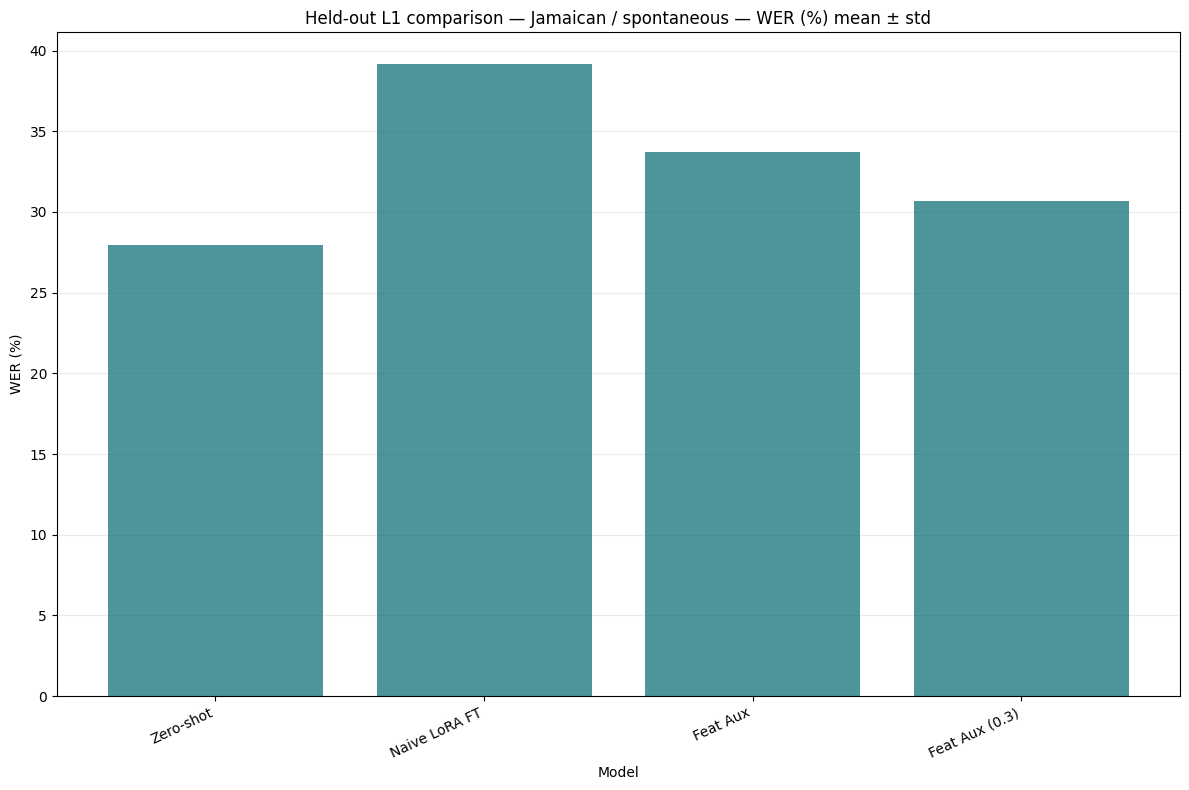

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

outdir = Path("output")
outdir.mkdir(exist_ok=True)

held_out_l1 = "Jamaican"
split = "spontaneous"
model_keys = [
    "baseline",
    "no_aux",
    # "no_aux_heldout_chinese",
    "feat_aux",
    # "feat_aux_heldout_chinese",
    "feat_aux0p3",

]

rows = []
for key in model_keys:
    if key not in results or split not in results[key]:
        continue

    df = results[key][split].copy()
    if "l1" not in df.columns:
        continue

    df = df[df["l1"] == held_out_l1]
    if len(df) == 0:
        continue

    row = {
        "model_key": key,
        "model": MODEL_KEYS.get(key, key),
        "n_utts": len(df),
        "n_speakers": df["speaker"].nunique() if "speaker" in df.columns else None,
        "wer_mean": corpus_wer(df) * 100,
    }

    if "utt_per" in df.columns:
        row["per_mean"] = df["utt_per"].mean()
        row["per_std"] = df["utt_per"].std()

    rows.append(row)

heldout_cmp = pd.DataFrame(rows).reset_index(drop=True)
heldout_cmp.to_csv(outdir / "heldout_l1_comparison.csv", index=False)

plot_df = heldout_cmp.copy()
plot_df["label"] = plot_df["model"] if "model" in plot_df.columns else plot_df["model_key"]

metrics = [("wer_mean", "WER (%)", "#01696f")]
# if "per_mean" in plot_df.columns and plot_df["per_mean"].notna().any():
#     metrics.append(("per_mean", "per_std", "PER", "#0b5177"))

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 8 * len(metrics)), sharex=True)
if len(metrics) == 1:
    axes = [axes]

x = range(len(plot_df))
for ax, (mean_col, title, color) in zip(axes, metrics):
    means = plot_df[mean_col].to_numpy()
    ax.bar(x, means, color=color, alpha=0.7, capsize=5)
    ax.set_ylabel(title)
    ax.set_title(f"Held-out L1 comparison — {held_out_l1} / {split} — {title} mean ± std")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(plot_df["label"], rotation=25, ha="right")
axes[-1].set_xlabel("Model")

fig.tight_layout()
fig.savefig(outdir / "heldout_l1_points_whiskers.png", dpi=200, bbox_inches="tight")
fig.show()
print(outdir / "heldout_l1_comparison.csv")
print(outdir / "heldout_l1_points_whiskers.png")

fmt = {
    c: "{:.3f}"
    for c in heldout_cmp.columns
    if c.startswith(("wer_", "per_"))
}


display(
    heldout_cmp.style
        .format(fmt)
        .set_caption(f"Held-out L1 comparison — {held_out_l1} / {split}")
)

In [59]:
import numpy as np
import pandas as pd

def align_for_sigtest(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    group_value: str | None = None,
    group_col: str = "l1",
    metric_col: str = "utt_wer",
) -> pd.DataFrame:
    a = df_a.copy()
    b = df_b.copy()

    if group_value is not None:
        a = a[a[group_col] == group_value].copy()
        b = b[b[group_col] == group_value].copy()

    cols_a = ["utterance_id", group_col, metric_col]
    cols_b = ["utterance_id", group_col, metric_col]

    merged = (
        a[cols_a]
        .rename(columns={metric_col: "score_a", group_col: f"{group_col}_a"})
        .merge(
            b[cols_b].rename(columns={metric_col: "score_b", group_col: f"{group_col}_b"}),
            on="utterance_id",
            how="inner",
        )
    )

    if group_value is None and f"{group_col}_a" in merged.columns:
        merged[group_col] = merged[f"{group_col}_a"]

    merged = merged.dropna(subset=["score_a", "score_b"]).copy()
    merged["diff"] = merged["score_a"] - merged["score_b"]   # positive => model B better
    return merged